<a href="https://colab.research.google.com/github/Janith303/SE4050-Deep-Learning-Lab-8/blob/main/Reinforcement_Learning_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# Define a simple Neural Network to approximate Q-values
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [3]:
# Function to train DQN under a specific epsilon
def train_dqn(epsilon_val, episodes=300):
    state_dim = 100  # Assuming 100 states for a 10x10 GridWorld
    action_dim = 4   # 4 directions

    model = DQN(state_dim, action_dim)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    rewards_history = []

    for episode in range(episodes):
        state = random.randint(0, state_dim - 1)
        total_reward = 0
        done = False

        while not done:
            # Epsilon-greedy action selection
            if random.random() < epsilon_val:
                action = random.randint(0, action_dim - 1)
            else:
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(np.eye(state_dim)[state])
                    q_values = model(state_tensor)
                    action = torch.argmax(q_values).item()

            # Simulated environment step (dummy transition for demonstration)
            next_state = (state + random.choice([-1, 1, 10, -10])) % state_dim
            reward = 1.0 if next_state == (state_dim - 1) else -0.01
            done = (next_state == state_dim - 1) or (total_reward < -50)

            # DQN Update (Q-learning target loss)
            state_tensor = torch.FloatTensor(np.eye(state_dim)[state])
            next_state_tensor = torch.FloatTensor(np.eye(state_dim)[next_state])

            with torch.no_grad():
                max_next_q = torch.max(model(next_state_tensor))
                target = reward + 0.9 * max_next_q

            current_q = model(state_tensor)[action]
            loss = criterion(current_q, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            state = next_state
            total_reward += reward

        rewards_history.append(total_reward)
    return rewards_history

In [4]:
# Test different epsilon values
epsilons = [0.1, 0.9]
results = {}

for eps in epsilons:
    print(f"Training DQN with epsilon = {eps}...")
    results[eps] = train_dqn(epsilon_val=eps)

Training DQN with epsilon = 0.1...
Training DQN with epsilon = 0.9...


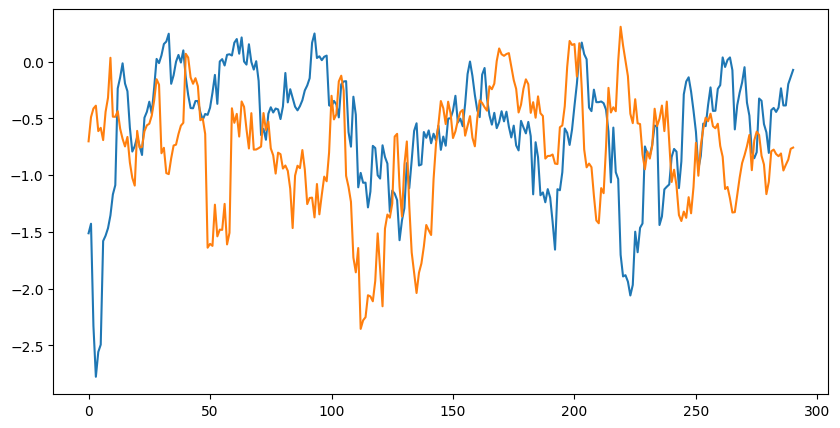

In [5]:
# Plotting the results
plt.figure(figsize=(10, 5))
for eps, rewards in results.items():
    # Smoothing out rewards for a cleaner plot curve
    smoothed_rewards = np.convolve(rewards, np.ones(10)/10, mode='valid')
    plt.plot(smoothed_rewards, label=f'Epsilon = {eps}')

plt.xlabel('Episodes')
plt.ylabel('Smoothed Total Reward')
plt.title('DQN Performance Comparison across Epsilon Values')
plt.legend()
plt.grid(True)
plt.show()